# 1. Data Overview

In [1]:

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv()

DATABASE_URL = os.getenv("DATABASE_URL")
if not DATABASE_URL:
    raise ValueError("DATABASE_URL not found in environment or .env")

engine = create_engine(DATABASE_URL)

TABLE_NAME = "pickup_features"
MAX_ROWS_FOR_PANDAS = 1_000_000
SAMPLE_IF_TOO_LARGE = True

row_count = pd.read_sql(
    text(f"SELECT COUNT(*) AS n FROM {TABLE_NAME}"),
    engine
).iloc[0]["n"]

print(f"Rows in {TABLE_NAME}: {row_count:,}")

columns = [
    "pulocationid",
    "hour_ts",
    "target_demand",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "temperature_mean",
    "precipitation_sum",
    "is_rainy",
    "is_heavy_rain",
    "is_hot",
    "demand_lag_1",
    "demand_lag_2",
    "demand_lag_24",
    "rolling_mean_3h",
    "borough_manhattan",
    "borough_brooklyn",
    "borough_queens",
    "borough_bronx",
    '"borough_staten island"',
    "borough_ewr",
    "borough_nan",
    '"service_zone_Yellow_Zone"',
    '"service_zone_Boro_Zone"',
    '"service_zone_Airports"',
    '"service_zone_EWR"',
    '"service_zone_nan"',
]

base_query = f"SELECT {', '.join(columns)} FROM {TABLE_NAME}"

if SAMPLE_IF_TOO_LARGE and row_count > MAX_ROWS_FOR_PANDAS:
    print(f"Table is large, loading a random sample of {MAX_ROWS_FOR_PANDAS:,} rows into pandas for EDA.")
    query = text(base_query + f" ORDER BY random() LIMIT {MAX_ROWS_FOR_PANDAS}")
else:
    print("Loading full table into pandas.")
    query = text(base_query)

df = pd.read_sql(query, engine, parse_dates=["hour_ts"])
df.head()


Rows in pickup_features: 6,430,288
Table is large, loading a random sample of 1,000,000 rows into pandas for EDA.


,pulocationid,hour_ts,target_demand,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,dow_sin,...,borough_queens,borough_bronx,borough_staten island,borough_ewr,borough_nan,service_zone_Yellow_Zone,service_zone_Boro_Zone,service_zone_Airports,service_zone_EWR,service_zone_nan
0,213,2023-11-28 02:00:00+00:00,15,2,1,11,0,0.500000,0.866026,0.781831,...,0,1,0,0,0,0,1,0,0,0
1,93,2025-03-19 13:00:00+00:00,14,13,2,3,0,-0.258816,-0.965927,0.974928,...,1,0,0,0,0,0,1,0,0,0
2,223,2023-07-11 07:00:00+00:00,151,7,1,7,0,0.965926,-0.258818,0.781831,...,1,0,0,0,0,0,1,0,0,0
3,262,2023-12-07 23:00:00+00:00,80,23,3,12,0,-0.258824,0.965925,0.433886,...,0,0,0,0,0,1,0,0,0,0
4,244,2023-04-11 17:00:00+00:00,256,17,1,4,0,-0.965925,-0.258823,0.781831,...,0,0,0,0,0,0,1,0,0,0


In [2]:

df.shape


(1000000, 32)

In [3]:

df.columns.tolist()


['pulocationid',
 'hour_ts',
 'target_demand',
 'hour',
 'day_of_week',
 'month',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'temperature_mean',
 'precipitation_sum',
 'is_rainy',
 'is_heavy_rain',
 'is_hot',
 'demand_lag_1',
 'demand_lag_2',
 'demand_lag_24',
 'rolling_mean_3h',
 'borough_manhattan',
 'borough_brooklyn',
 'borough_queens',
 'borough_bronx',
 'borough_staten island',
 'borough_ewr',
 'borough_nan',
 'service_zone_Yellow_Zone',
 'service_zone_Boro_Zone',
 'service_zone_Airports',
 'service_zone_EWR',
 'service_zone_nan']

In [4]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                    Non-Null Count    Dtype              
---  ------                    --------------    -----              
 0   pulocationid              1000000 non-null  int64              
 1   hour_ts                   1000000 non-null  datetime64[ns, UTC]
 2   target_demand             1000000 non-null  int64              
 3   hour                      1000000 non-null  int64              
 4   day_of_week               1000000 non-null  int64              
 5   month                     1000000 non-null  int64              
 6   is_weekend                1000000 non-null  int64              
 7   hour_sin                  1000000 non-null  float64            
 8   hour_cos                  1000000 non-null  float64            
 9   dow_sin                   1000000 non-null  float64            
 10  dow_cos                   1000000 non-null  float64    

In [5]:
borough_cols = [
    "borough_manhattan",
    "borough_brooklyn",
    "borough_queens",
    "borough_bronx",
    "borough_staten island",
    "borough_ewr",
    "borough_nan",
]

service_zone_cols = [
    "service_zone_Yellow_Zone",
    "service_zone_Boro_Zone",
    "service_zone_Airports",
    "service_zone_EWR",
    "service_zone_nan",
]

borough_map = {
    "borough_manhattan": "Manhattan",
    "borough_brooklyn": "Brooklyn",
    "borough_queens": "Queens",
    "borough_bronx": "Bronx",
    "borough_staten island": "Staten Island",
    "borough_ewr": "EWR",
    "borough_nan": "Unknown",
}

service_zone_map = {
    "service_zone_Yellow_Zone": "Yellow Zone",
    "service_zone_Boro_Zone": "Boro Zone",
    "service_zone_Airports": "Airports",
    "service_zone_EWR": "EWR",
    "service_zone_nan": "Unknown",
}

df["borough"] = df[borough_cols].idxmax(axis=1).map(borough_map)
df["service_zone"] = df[service_zone_cols].idxmax(axis=1).map(service_zone_map)
df["pickup_date"] = df["hour_ts"].dt.date

df[["pulocationid", "borough", "service_zone"]].head()

,pulocationid,borough,service_zone
0,213,Bronx,Boro Zone
1,93,Queens,Boro Zone
2,223,Queens,Boro Zone
3,262,Manhattan,Yellow Zone
4,244,Manhattan,Boro Zone


# 2. Missing Values Analysis

In [6]:

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)



=== MISSING VALUES ===


,missing_count,missing_pct


# 3. Target and Feature Distributions

In [7]:

df["target_demand"].describe()


count    1000000.000000
mean         122.653222
std          150.878497
min            1.000000
25%           28.000000
50%           73.000000
75%          158.000000
max         2283.000000
Name: target_demand, dtype: float64

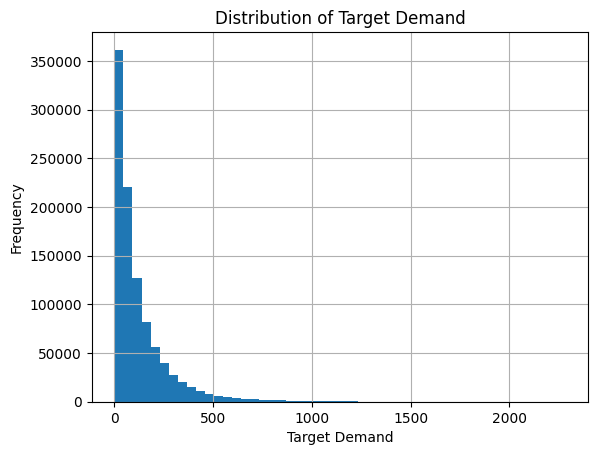

In [8]:

df["target_demand"].hist(bins=50)
plt.title("Distribution of Target Demand")
plt.xlabel("Target Demand")
plt.ylabel("Frequency")
plt.show()


In [9]:

feature_cols = ["temperature_mean", "precipitation_sum", "demand_lag_1", "demand_lag_2", "demand_lag_24", "rolling_mean_3h"]
df[feature_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
temperature_mean,1000000.0,12.466649,8.955894,-11.6,5.2,12.500000,20.2,34.800000
precipitation_sum,1000000.0,3.527594,8.394620,0.0,0.0,0.000000,2.7,100.200000
demand_lag_1,1000000.0,122.601465,150.764081,1.0,28.0,73.000000,158.0,3480.000000
demand_lag_2,1000000.0,122.543900,150.675536,1.0,28.0,73.000000,158.0,2668.000000
demand_lag_24,1000000.0,122.536313,150.420820,1.0,28.0,73.000000,158.0,2449.000000
rolling_mean_3h,1000000.0,122.528370,147.201283,1.0,30.0,74.333333,158.0,2336.666667


# 4. Temporal Patterns

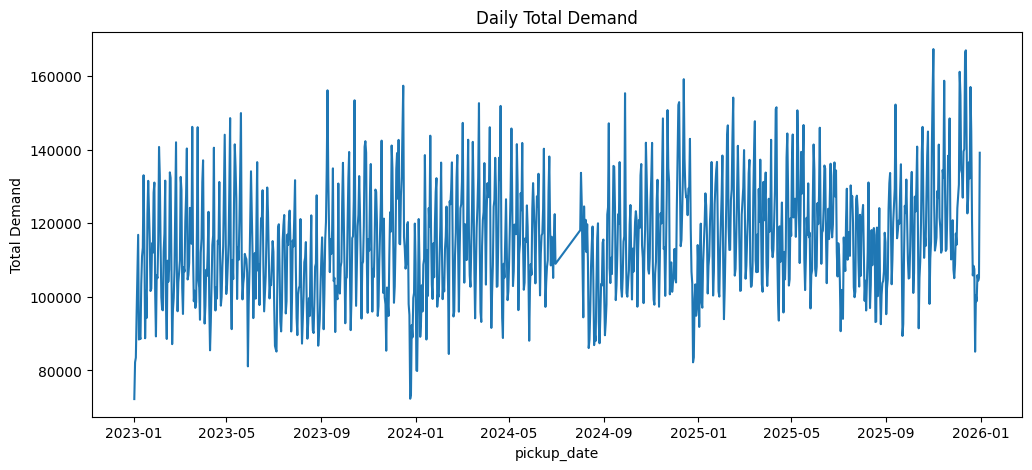

In [10]:

daily_demand = df.groupby("pickup_date")["target_demand"].sum().sort_index()
daily_demand.plot(figsize=(12, 5), title="Daily Total Demand")
plt.ylabel("Total Demand")
plt.show()


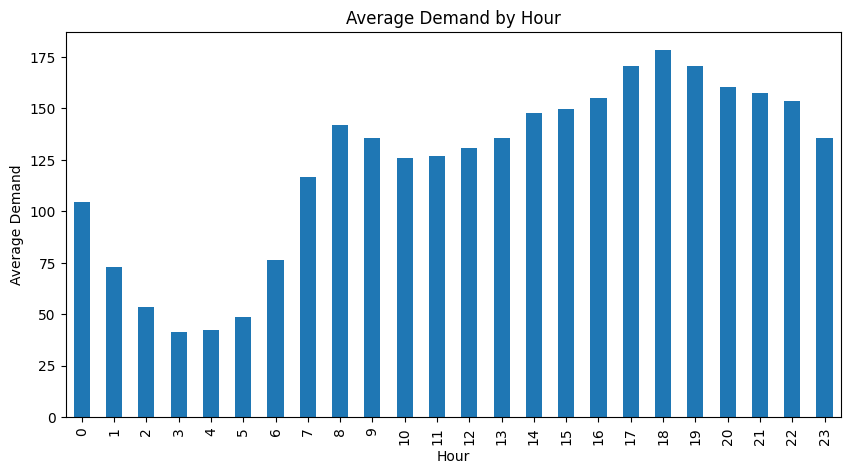

In [11]:

hourly_demand = (
    df.groupby("hour")["target_demand"]
    .mean()
    .reindex(range(24), fill_value=0)
)

hourly_demand.plot(kind="bar", figsize=(10, 5), title="Average Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Demand")
plt.show()


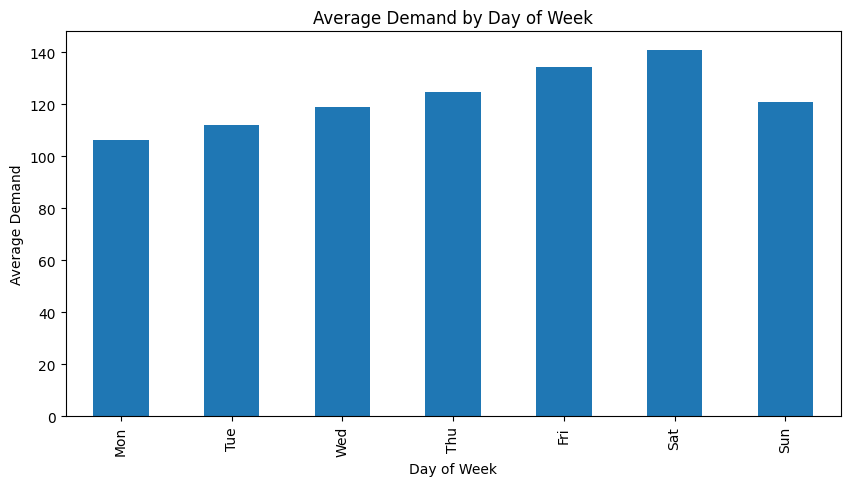

In [12]:

day_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

daily_pattern = (
    df.groupby("day_of_week")["target_demand"]
    .mean()
    .reindex(range(7), fill_value=0)
)
daily_pattern.index = daily_pattern.index.map(day_map)

daily_pattern.plot(kind="bar", figsize=(10, 5), title="Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.show()


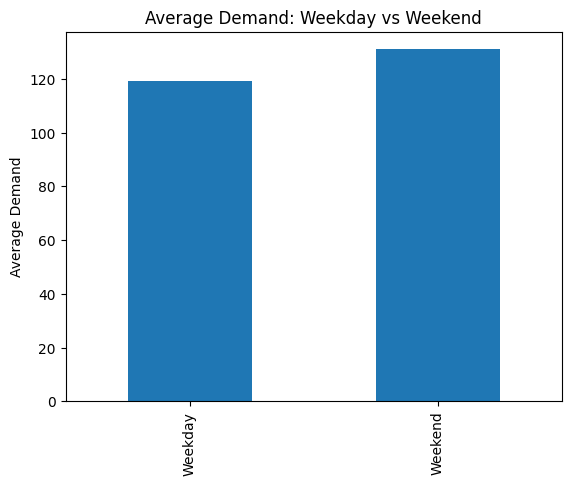

In [13]:

weekend_demand = df.groupby("is_weekend")["target_demand"].mean().reindex([0, 1], fill_value=0)
weekend_demand.index = ["Weekday", "Weekend"]

weekend_demand.plot(kind="bar", title="Average Demand: Weekday vs Weekend")
plt.xlabel("")
plt.ylabel("Average Demand")
plt.show()


# 5. Weather Impact

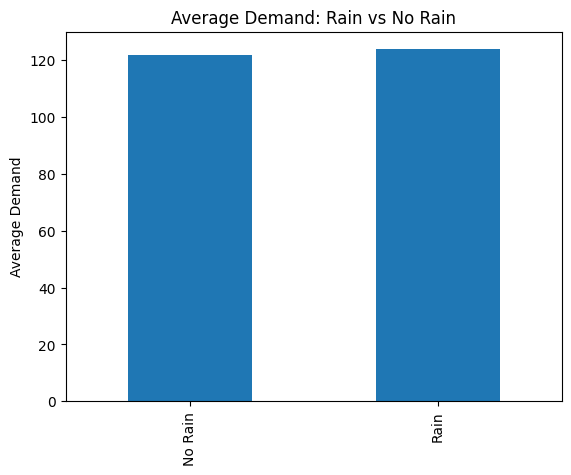

In [14]:

rain_demand = df.groupby("is_rainy")["target_demand"].mean().reindex([0, 1], fill_value=0)
rain_demand.index = ["No Rain", "Rain"]

rain_demand.plot(kind="bar", title="Average Demand: Rain vs No Rain")
plt.xlabel("")
plt.ylabel("Average Demand")
plt.show()


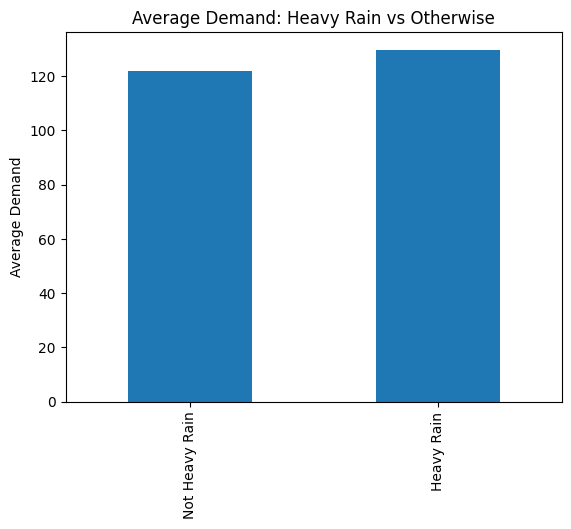

In [15]:

heavy_rain_demand = df.groupby("is_heavy_rain")["target_demand"].mean().reindex([0, 1], fill_value=0)
heavy_rain_demand.index = ["Not Heavy Rain", "Heavy Rain"]

heavy_rain_demand.plot(kind="bar", title="Average Demand: Heavy Rain vs Otherwise")
plt.xlabel("")
plt.ylabel("Average Demand")
plt.show()


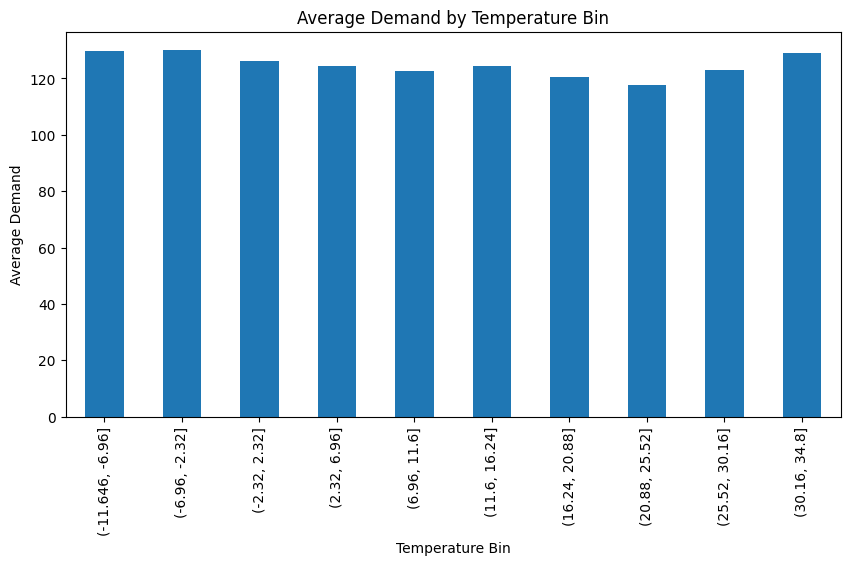

In [16]:

temp_demand = df.dropna(subset=["temperature_mean", "target_demand"]).copy()
temp_demand["temp_bin"] = pd.cut(temp_demand["temperature_mean"], bins=10)

temp_demand.groupby("temp_bin", observed=False)["target_demand"].mean().plot(
    kind="bar", figsize=(10, 5), title="Average Demand by Temperature Bin"
)
plt.xlabel("Temperature Bin")
plt.ylabel("Average Demand")
plt.show()


# 6. Lag Feature Relationships

In [17]:

lag_cols = ["demand_lag_1", "demand_lag_2", "demand_lag_24", "rolling_mean_3h"]
df[lag_cols + ["target_demand"]].corr()[["target_demand"]].sort_values("target_demand", ascending=False)


,target_demand
target_demand,1.000000
demand_lag_1,0.956475
rolling_mean_3h,0.903058
demand_lag_24,0.903032
demand_lag_2,0.886100


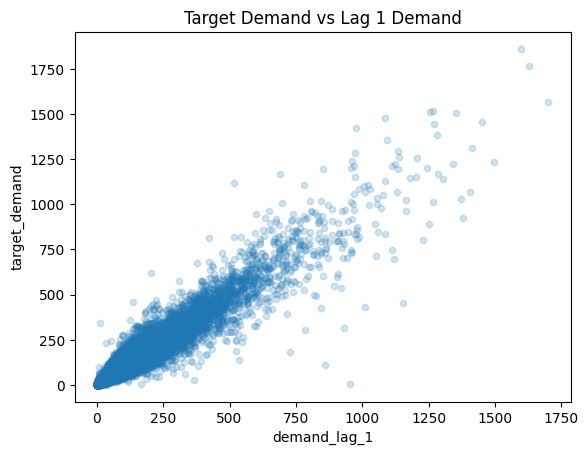

In [18]:

sample_df = df.sample(min(len(df), 20000), random_state=42)

sample_df.plot.scatter(
    x="demand_lag_1",
    y="target_demand",
    alpha=0.2,
    title="Target Demand vs Lag 1 Demand"
)
plt.show()


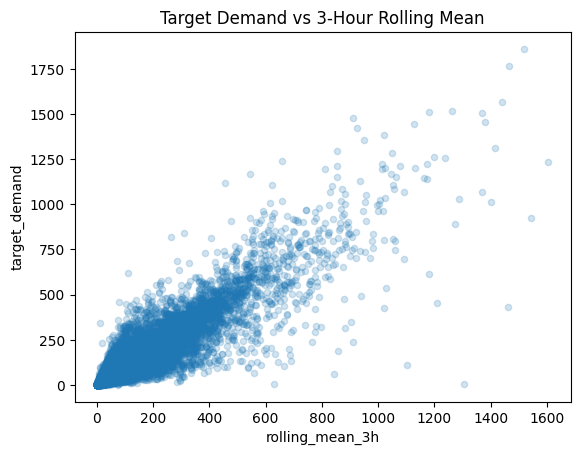

In [19]:

sample_df.plot.scatter(
    x="rolling_mean_3h",
    y="target_demand",
    alpha=0.2,
    title="Target Demand vs 3-Hour Rolling Mean"
)
plt.show()


# 7. Location Analysis

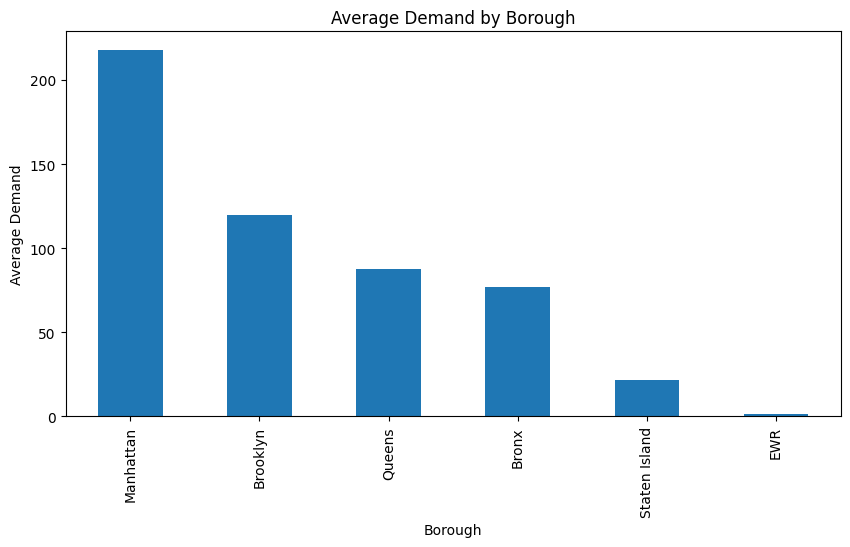

In [20]:

borough_demand = df.groupby("borough")["target_demand"].mean().sort_values(ascending=False)
borough_demand.plot(kind="bar", figsize=(10, 5), title="Average Demand by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Demand")
plt.show()


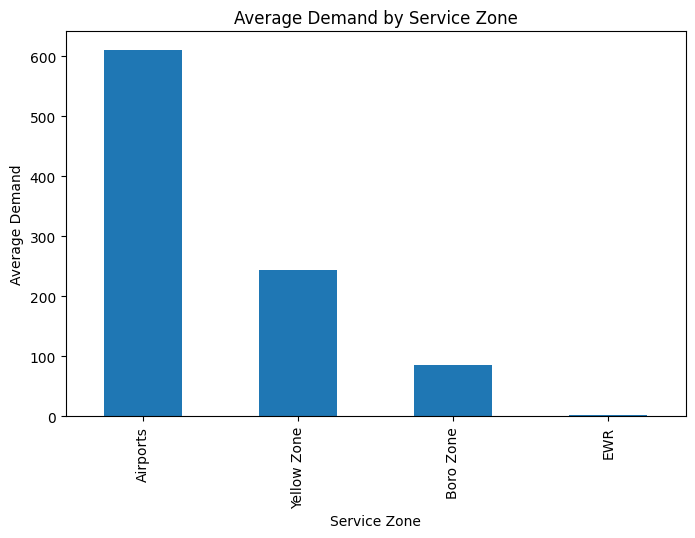

In [21]:

service_zone_demand = df.groupby("service_zone")["target_demand"].mean().sort_values(ascending=False)
service_zone_demand.plot(kind="bar", figsize=(8, 5), title="Average Demand by Service Zone")
plt.xlabel("Service Zone")
plt.ylabel("Average Demand")
plt.show()


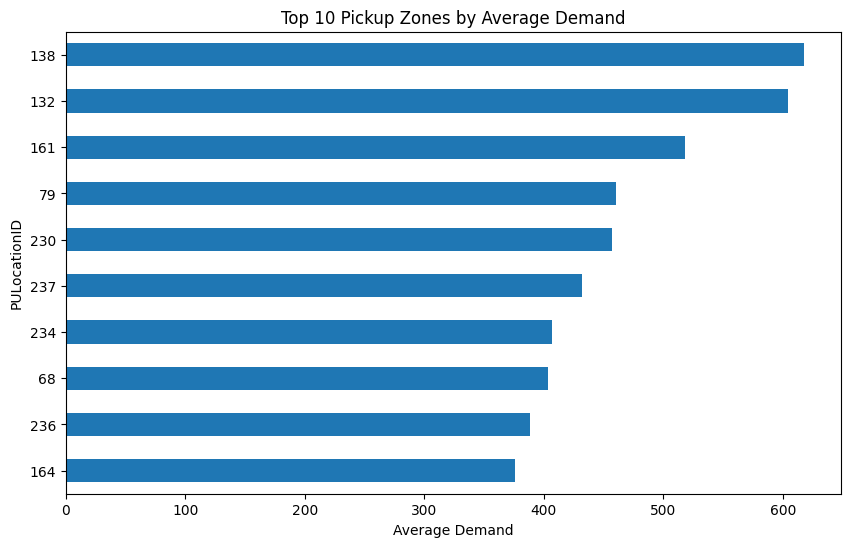

In [22]:

top_zones = (
    df.groupby("pulocationid")["target_demand"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_zones.sort_values().plot(kind="barh", figsize=(10, 6), title="Top 10 Pickup Zones by Average Demand")
plt.xlabel("Average Demand")
plt.ylabel("PULocationID")
plt.show()


# 8. Correlation Analysis

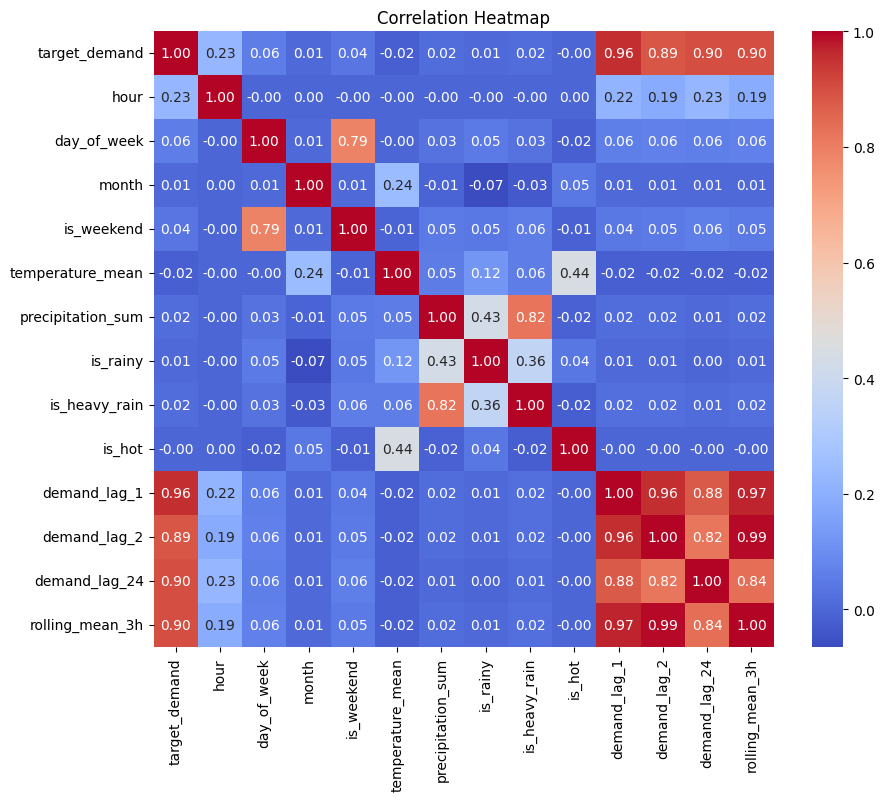

In [23]:

numeric_cols = [
    "target_demand",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "temperature_mean",
    "precipitation_sum",
    "is_rainy",
    "is_heavy_rain",
    "is_hot",
    "demand_lag_1",
    "demand_lag_2",
    "demand_lag_24",
    "rolling_mean_3h",
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
